DEVICE: cuda
Manifest: (75000, 9)
Train: (51245, 10)
Val: (10911, 10)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Epoch 1/30


100%|██████████| 455/455 [03:08<00:00,  2.41it/s]


Train Loss: 0.9358
Patient F1: 0.4049
Saved Best Model

Epoch 2/30


...

Train Loss: 0.1684
Patient F1: 0.4852

Epoch 25/30


100%|██████████| 455/455 [01:35<00:00,  4.75it/s]


Train Loss: 0.1618
Patient F1: 0.5196
Early Stopping

BEST F1: 0.6093920699183857


Evaluating: 100%|██████████| 455/455 [01:27<00:00,  5.22it/s]



Accuracy: 0.6862745098039216
              precision    recall  f1-score   support

        LumA       0.73      0.80      0.76        20
        LumB       0.62      0.76      0.68        17
        Her2       0.50      0.14      0.22         7
       Basal       0.83      0.71      0.77         7

    accuracy                           0.69        51
   macro avg       0.67      0.61      0.61        51
weighted avg       0.67      0.69      0.66        51



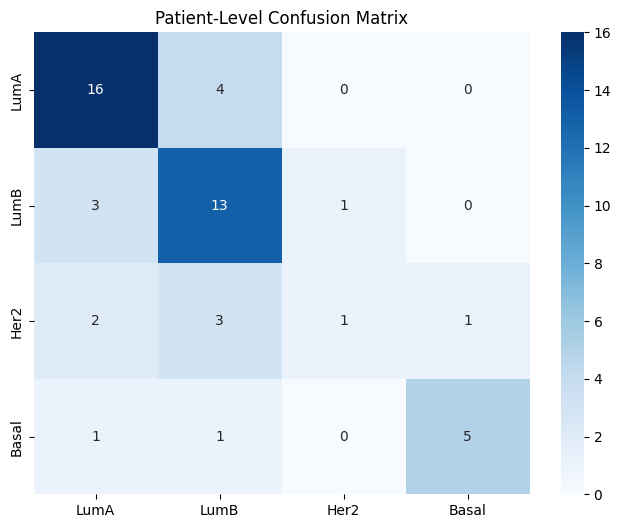

Macro ROC-AUC: 0.8465696361345987

Saved:
best_effnet_b3.pth
patient_predictions.csv
confusion_matrix.png


In [1]:
!pip install -q timm albumentations

import os
import gc
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import seaborn as sns
import matplotlib.pyplot as plt

############################################################
# SEED
############################################################

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

############################################################
# LOAD MANIFEST
############################################################

MANIFEST_DIR = (
    "/kaggle/input/datasets/hritishachoudhury/bc-xai-quality-filtering"
)

df = pd.read_csv(
    f"{MANIFEST_DIR}/filtered_manifest.csv"
)

print("Manifest:", df.shape)

############################################################
# LABELS
############################################################

label_map = {
    "LumA":0,
    "LumB":1,
    "Her2":2,
    "Basal":3
}

df["label"] = (
    df["subtype_clean"]
    .map(label_map)
)

train_df = (
    df[df.split=="train"]
    .reset_index(drop=True)
)

val_df = (
    df[df.split=="val"]
    .reset_index(drop=True)
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)

############################################################
# DATASET ROOTS
############################################################

DATASET_ROOTS = {
    "bc-xai-a2-2000-partial":
    "/kaggle/input/datasets/anishapanja/bc-xai-a2-2000-partial",

    "bc-xai-e2-2000":
    "/kaggle/input/datasets/anishapanja/bc-xai-e2-2000",

    "bc-xai-a8-patches-batch1":
    "/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch1",

    "bc-xai-a8-patches-batch2":
    "/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch2",

    "bc-xai-a8-patches-batch3":
    "/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch3",

    "bc-xai-a8-patches-batch4":
    "/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch4",

    "bc-xai-a8-patches-batch5":
    "/kaggle/input/datasets/anishapanja/bc-xai-a8-patches-batch5",

    "bc-xai-c8-patches-batch1":
    "/kaggle/input/datasets/anishapanja/bc-xai-c8-patches-batch1",

    "bc-xai-c8-patches-batch2":
    "/kaggle/input/datasets/anishapanja/bc-xai-c8-patches-batch2",

    "bc-xai-c8-patches-batch3":
    "/kaggle/input/datasets/anishapanja/bc-xai-c8-patches-batch3",

    "bc-xai-c8-patches-batch4":
    "/kaggle/input/datasets/anishapanja/bc-xai-c8-patches-batch4",

    "bc-xai-bh-patches":
    "/kaggle/input/datasets/hritishachoudhury/bc-xai-bh-patches",

    "bc-xai-d8-patches":
    "/kaggle/input/datasets/hritishachoudhury/bc-xai-d8-patches"
}

############################################################
# PATH
############################################################

def get_path(row):

    root = DATASET_ROOTS[row["dataset"]]

    return os.path.join(
        root,
        row["relative_path"]
    )

############################################################
# AUGMENTATIONS
############################################################

train_tfms = A.Compose([
    A.RandomResizedCrop(
        size=(300,300),
        scale=(0.8,1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=90,p=0.5),
    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.7
    ),
    A.RandomGamma(
        gamma_limit=(80,120),
        p=0.4
    ),
    A.GaussNoise(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(300,300),
    A.Normalize(),
    ToTensorV2()
])

############################################################
# DATASET
############################################################

class BCDataset(Dataset):

    def __init__(self, df, transforms):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            get_path(row)
        ).convert("RGB")

        img = np.array(img)

        img = self.transforms(
            image=img
        )["image"]

        label = int(row.label)
        patient = row.patient_id

        return img, label, patient

############################################################
# DATALOADERS
############################################################

counts = train_df.label.value_counts()

weights = len(train_df) / counts

sample_weights = (
    train_df.label
    .map(weights)
)

sampler = WeightedRandomSampler(
    sample_weights.values,
    len(sample_weights),
    replacement=True
)

train_ds = BCDataset(
    train_df,
    train_tfms
)

val_ds = BCDataset(
    val_df,
    val_tfms
)

train_loader = DataLoader(
    train_ds,
    batch_size=24,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=24,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

############################################################
# MODEL
############################################################

model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=4,
    drop_rate=0.4
)

model = model.to(DEVICE)

############################################################
# LOSS
############################################################

class FocalLoss(nn.Module):

    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(
        self,
        logits,
        targets
    ):

        ce = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=0.1
        )

        pt = torch.exp(-ce)

        loss = ((1-pt)**self.gamma) * ce

        return loss.mean()

criterion = FocalLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

scaler = torch.amp.GradScaler("cuda")

############################################################
# TRAINING
############################################################

BEST = 0
PATIENCE = 8
counter = 0

for epoch in range(30):

    print(f"\nEpoch {epoch+1}/30")

    model.train()

    losses = []

    for images, labels, _ in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())

    ########################################################

    model.eval()

    patient_probs = {}

    with torch.no_grad():

        for images, labels, patients in tqdm(val_loader):

            images = images.to(DEVICE)

            logits = model(images)

            probs = F.softmax(
                logits,
                dim=1
            )

            probs = probs.cpu().numpy()

            for p, prob in zip(
                patients,
                probs
            ):

                if p not in patient_probs:
                    patient_probs[p] = []

                patient_probs[p].append(prob)

    gt = (
        val_df
        .groupby("patient_id")
        .first()
    )

    preds = []
    targets = []

    for patient in patient_probs:

        avg = np.mean(
            patient_probs[patient],
            axis=0
        )

        pred = np.argmax(avg)

        target = gt.loc[
            patient,
            "label"
        ]

        preds.append(pred)
        targets.append(target)

    f1 = f1_score(
        targets,
        preds,
        average="macro"
    )

    print(
        "Train Loss:",
        round(np.mean(losses),4)
    )

    print(
        "Patient F1:",
        round(f1,4)
    )

    scheduler.step()

    if f1 > BEST:

        BEST = f1
        counter = 0

        torch.save(
            model.state_dict(),
            "best_effnet_b3.pth"
        )

        print("Saved Best Model")

    else:
        counter += 1

    if counter >= PATIENCE:
        print("Early Stopping")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("\nBEST F1:", BEST)

############################################################
# FINAL EVALUATION
############################################################

model.load_state_dict(
    torch.load(
        "best_effnet_b3.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

model.eval()

patient_probs = {}

with torch.no_grad():

    for images, labels, patients in tqdm(
        val_loader,
        desc="Evaluating"
    ):

        images = images.to(DEVICE)

        logits = model(images)

        probs = F.softmax(
            logits,
            dim=1
        )

        probs = probs.cpu().numpy()

        for p, prob in zip(
            patients,
            probs
        ):

            if p not in patient_probs:
                patient_probs[p] = []

            patient_probs[p].append(prob)

gt = (
    val_df
    .groupby("patient_id")
    .first()
)

preds = []
targets = []
avg_probs = []
patient_ids = []

for patient in patient_probs:

    avg = np.mean(
        patient_probs[patient],
        axis=0
    )

    pred = np.argmax(avg)

    target = gt.loc[
        patient,
        "label"
    ]

    preds.append(pred)
    targets.append(target)
    avg_probs.append(avg)
    patient_ids.append(patient)

avg_probs = np.array(avg_probs)

print("\nAccuracy:",
      accuracy_score(targets,preds))

print(
    classification_report(
        targets,
        preds,
        target_names=[
            "LumA",
            "LumB",
            "Her2",
            "Basal"
        ]
    )
)

cm = confusion_matrix(
    targets,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "LumA",
        "LumB",
        "Her2",
        "Basal"
    ],
    yticklabels=[
        "LumA",
        "LumB",
        "Her2",
        "Basal"
    ]
)

plt.title(
    "Patient-Level Confusion Matrix"
)

plt.show()

auc = roc_auc_score(
    label_binarize(
        targets,
        classes=[0,1,2,3]
    ),
    avg_probs,
    average="macro",
    multi_class="ovr"
)

print("Macro ROC-AUC:", auc)

pd.DataFrame({
    "patient_id":patient_ids,
    "true":targets,
    "pred":preds
}).to_csv(
    "patient_predictions.csv",
    index=False
)

print("\nSaved:")
print("best_effnet_b3.pth")
print("patient_predictions.csv")
print("confusion_matrix.png")